# Attack-direction selection: activation-space feasibility oracle

Этот ноутбук **не генерирует новый adversarial patch**. Он в контролируемом offline setting проверяет, какой внутренний objective способен причинно воспроизвести target hiding при одинаковом L2-бюджете на Detect input. Это дешёвый gate перед любым будущим исследованием pixel-space objectives.

## Неудачные направления, которые не следует повторять как основной objective

- **Только fixed clean cell.** Sparse top-negative transplant очень сильно подавляет его logit, но даёт практически 0% object hiding. Причина: detector сохраняет объект другим кандидатом.
- **Статический clean candidate set как достаточное объяснение.** Его signed suppression снижает set score, но почти не скрывает target; при больших k начинается handoff за пределы clean set.
- **Global maximum person confidence.** Objective не соответствует target-aware success и может «успешно» заменить одного человека другим.

Поэтому сравниваются fixed-cell, static clean set и differentiable dynamic score+geometry risk. Последний считается перспективным только если hiding достигается при меньшем бюджете и не сводится к одному fixed logit.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'CandidateRoutingAndAttackPath' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
sns.set_theme(style='whitegrid', context='notebook')
print(REPO_ROOT)

/Users/ashentide/PycharmProjects/PatchSuccessResearch


## Загрузка результатов

Тяжёлое вычисление вынесено в Python-скрипт. Этот ноутбук только читает компактные CSV/JSON и строит графики. Расширенный MPS-запуск: `conda run -n IAD python -m CandidateRoutingAndAttackPath.run_followup_experiments attack --device mps`.

## Threat model и ограничения

Оптимизируется additive perturbation только на target P5 Detect input конкретного примера. Радиус L2 равен норме уже наблюдавшегося clean→patched P5 delta. Поэтому эксперимент показывает **внутреннюю достижимость endpoint**, но не физическую, универсальную или pixel-space реализуемость. Cosine с реальным patch delta сохраняется как диагностическая проверка направления.

In [2]:
candidates = sorted((p.parent for p in (REPO_ROOT/'CandidateRoutingAndAttackPath'/'followup_outputs').glob('attack_oracle_*/summary.json')), key=lambda p: p.stat().st_mtime)
run_dir = candidates[-1]
print(run_dir)
display(json.loads((run_dir/'summary.json').read_text()))

/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/attack_oracle_f2be745bbc7372f0


{'status': 'complete',
 'elapsed_seconds': 160.6139898300171,
 'n_examples': 100,
 'final_hiding_rate': {'dynamic_score_geometry': 1.0,
  'fixed_cell': 0.82,
  'static_clean_set': 1.0},
 'final_relative_norm': {'dynamic_score_geometry': 0.14679615849881397,
  'fixed_cell': 0.2749863591571428,
  'static_clean_set': 0.19309777215131244},
 'cache_path': '/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/new_experiments/outputs/patch_success_analysis/cache/attack_pool_d60ec9ed15ee6591.pkl',
 'config': {'output_dir': '/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs',
  'device': 'mps',
  'require_device': True,
  'examples_per_group': 25,
  'objectives': ['fixed_cell', 'static_clean_set', 'dynamic_score_geometry'],
  'steps': 20,
  'checkpoints': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20],
  'epsilon_actual_l2_fraction': 1.0,
  

In [3]:
rows = pd.read_csv(run_dir/'attack_oracle_rows.csv')
summary = pd.read_csv(run_dir/'attack_oracle_summary.csv')
first_path = run_dir/'attack_oracle_first_hiding_summary.csv'
first_hiding = pd.read_csv(first_path) if first_path.exists() else pd.DataFrame()
display(summary)
if len(first_hiding): display(first_hiding)

,objective,step,n,target_hidden_rate,mean_relative_actual_l2,mean_cosine_actual_delta,mean_fixed_logit,mean_fixed_iou,mean_post_conf,mean_post_iou,nms_only_hidden_rate
0,dynamic_score_geometry,0,100,0.00,0.000000,0.000000,2.228257,1.000000,0.901514,1.000000,0.0
1,dynamic_score_geometry,1,100,0.00,0.020000,0.011796,0.128055,0.998630,0.680020,0.983859,0.0
2,dynamic_score_geometry,2,100,0.27,0.036061,0.013978,-1.863654,0.997547,0.323671,0.960114,0.0
3,dynamic_score_geometry,3,100,0.93,0.050203,0.016068,-4.524313,0.996782,0.108124,0.910588,0.0
4,dynamic_score_geometry,4,100,0.98,0.061217,0.016110,-6.636861,0.996186,0.025657,0.579136,0.0
...,...,...,...,...,...,...,...,...,...,...,...
58,static_clean_set,16,100,1.00,0.164865,0.013826,-51.328821,0.992070,0.000000,0.026871,0.0
59,static_clean_set,17,100,1.00,0.172559,0.013536,-55.367822,0.991680,0.000000,0.026872,0.0
60,static_clean_set,18,100,1.00,0.179779,0.013303,-60.673733,0.991360,0.000000,0.026871,0.0
61,static_clean_set,19,100,1.00,0.186494,0.013053,-66.146363,0.991023,0.000000,0.026871,0.0


,objective,n,hiding_success_rate,mean_first_hiding_step,median_first_hiding_step,mean_first_hiding_norm,median_first_hiding_norm,mean_cosine_actual_delta
0,dynamic_score_geometry,100,1.00,2.820000,3.0,0.047597,0.050453,0.015803
1,fixed_cell,100,0.82,10.280488,10.0,0.135591,0.115596,0.002839
2,static_clean_set,100,1.00,2.830000,3.0,0.047766,0.050567,0.015737


## 1. Sufficiency dose-response

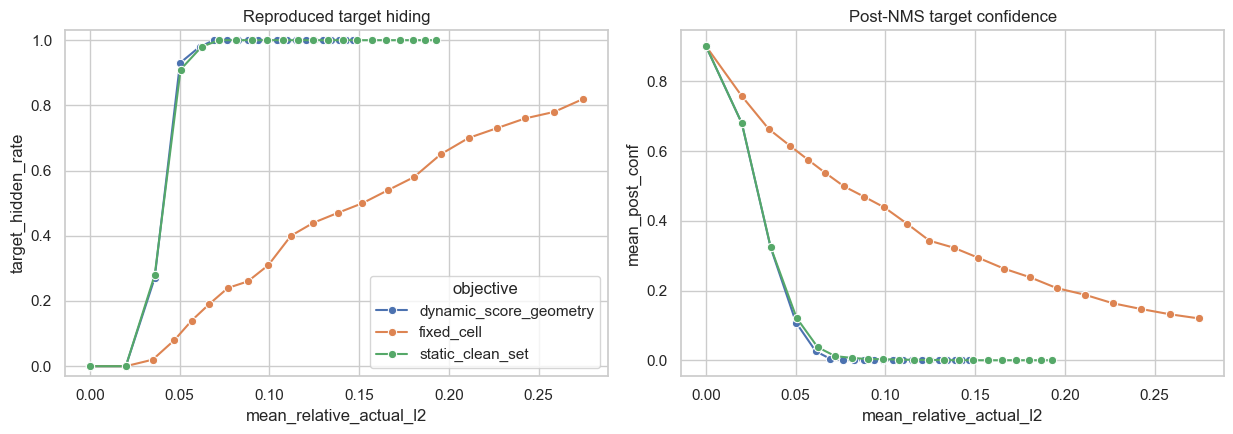

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
sns.lineplot(data=summary, x='mean_relative_actual_l2', y='target_hidden_rate', hue='objective', marker='o', ax=axes[0])
sns.lineplot(data=summary, x='mean_relative_actual_l2', y='mean_post_conf', hue='objective', marker='o', ax=axes[1])
axes[0].set_ylim(-.03, 1.03); axes[0].set_title('Reproduced target hiding'); axes[1].set_title('Post-NMS target confidence')
axes[1].legend_.remove(); plt.tight_layout(); plt.show()

Dynamic и static candidate-set objectives практически совпадают в области первого hiding: оба достигают 100% успеха, средний первый hiding возникает на шагах 2.82–2.83 при норме около 0.048 от реальной patch delta; в 97 из 100 примеров первый успешный шаг одинаков. Fixed-cell заметно хуже: только 82% когда-либо скрыты, средний первый успех — шаг 10.3 и норма 0.136. Это подтверждает необходимость воздействовать на ensemble кандидатов, но не подтверждает преимущество dynamic routing над заранее выбранным clean candidate set.

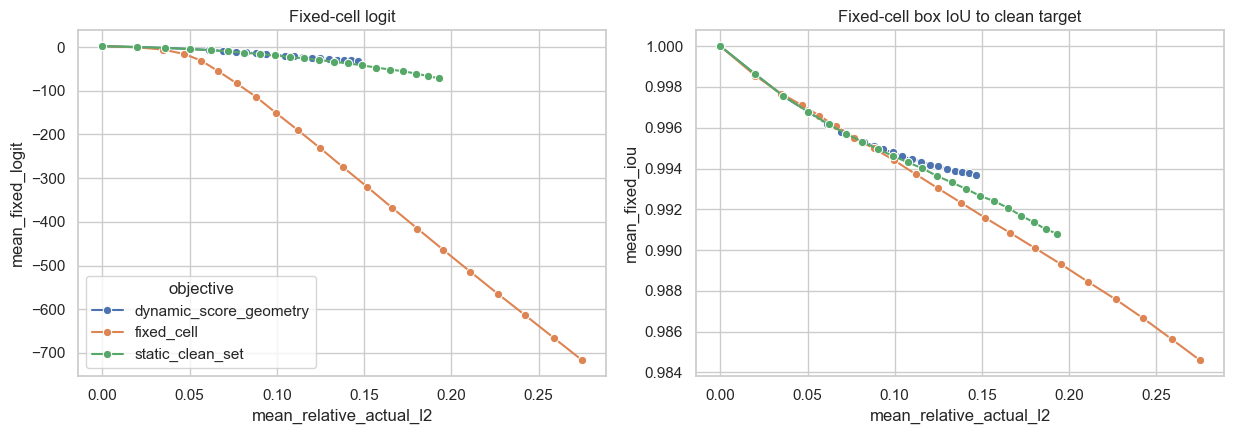

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
sns.lineplot(data=summary, x='mean_relative_actual_l2', y='mean_fixed_logit', hue='objective', marker='o', ax=axes[0])
sns.lineplot(data=summary, x='mean_relative_actual_l2', y='mean_fixed_iou', hue='objective', marker='o', ax=axes[1])
axes[0].set_title('Fixed-cell logit'); axes[1].set_title('Fixed-cell box IoU to clean target')
axes[1].legend_.remove(); plt.tight_layout(); plt.show()

Dynamic/static скрывают объект почти исключительно через score suppression: к шагу 3 hiding составляет 93%/91%, fixed-box IoU всё ещё около 0.997, а post-target confidence падает до 0.108/0.122. Fixed-cell при этом доводит один logit до огромных отрицательных значений, но post-target confidence остаётся высоким из-за candidate handoff. Geometry-компонента dynamic objective фактически не была нужна в найденной low-budget области.

## 2. Различия между исходными outcome-группами

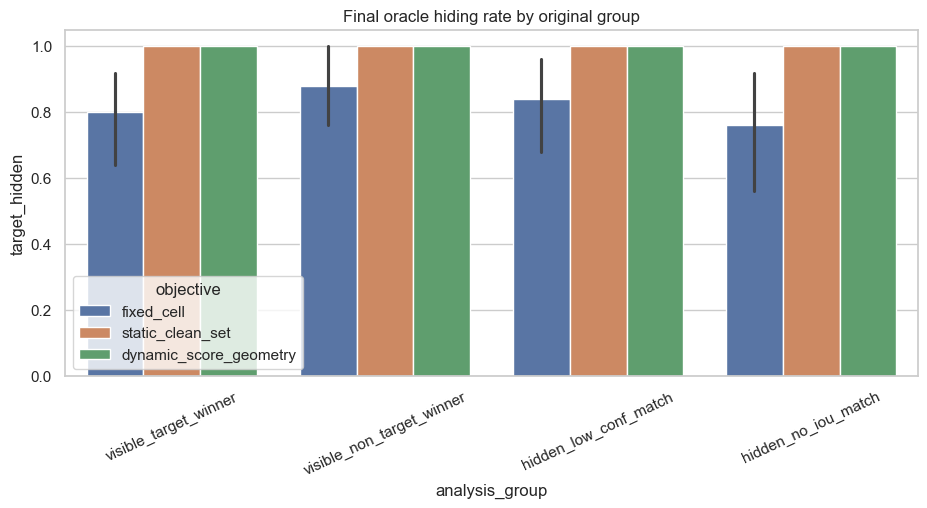

In [6]:
final = rows[rows.step == rows.step.max()]
order = ['visible_target_winner','visible_non_target_winner','hidden_low_conf_match','hidden_no_iou_match']
plt.figure(figsize=(11, 4.5))
sns.barplot(data=final, x='analysis_group', y='target_hidden', hue='objective', order=order)
plt.ylim(0, 1.05); plt.title('Final oracle hiding rate by original group'); plt.xticks(rotation=25); plt.show()

Dynamic и static objectives дают 100% hiding во всех четырёх исходных outcome-группах; fixed-cell остаётся на 76–88%. Следовательно, найдено общее activation-space направление подавления target-candidate ensemble, а не механизм, специфичный для примеров, которые скрывает исходный патч. Это полезный causal oracle, но слабое объяснение различия patch success/failure.

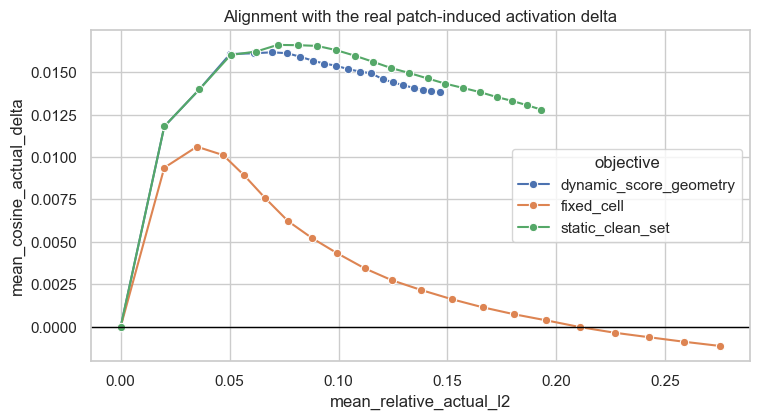

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
sns.lineplot(data=summary, x='mean_relative_actual_l2', y='mean_cosine_actual_delta', hue='objective', marker='o', ax=ax)
ax.axhline(0, color='black', lw=1); ax.set_title('Alignment with the real patch-induced activation delta'); plt.show()

Cosine оптимизированных направлений с реальной patch-induced delta остаётся около 0.01–0.02, то есть почти равен нулю. Модель допускает дешёвое activation-space подавление объекта, но исходный patch приходит к hiding другим направлением. Поэтому переносить этот oracle напрямую в pixel-space attack objective пока не обосновано; следующий attack-тест должен проверять realizability и alignment, а не ещё раз увеличивать activation budget.

In [ ]:
decision = final.groupby('objective').agg(hiding=('target_hidden','mean'), norm=('relative_actual_l2','mean'), cosine=('cosine_with_actual_patch_delta','mean'), conf=('post_target_conf','mean')).sort_values(['hiding','norm'], ascending=[False,True])
display(decision)
winner = decision.index[0]
display(Markdown(f'**Автоматический gate:** лучший activation-space objective — `{winner}`. Продолжать направление имеет смысл только после проверки индивидуальных примеров, устойчивости по seed и того, что преимущество не исчезает при меньшем общем L2 budget.'))

,hiding,norm,cosine,conf
objective,,,,
dynamic_score_geometry,1.00,0.146796,0.013806,0.000000
static_clean_set,1.00,0.193098,0.012790,0.000000
fixed_cell,0.82,0.274986,-0.001140,0.119888


**Автоматический gate:** лучший activation-space objective — `dynamic_score_geometry`. Продолжать направление имеет смысл только после проверки индивидуальных примеров, устойчивости по seed и того, что преимущество не исчезает при меньшем общем L2 budget.

: 